In [4]:
pip install openCV-python


  Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl (39.5 MB)


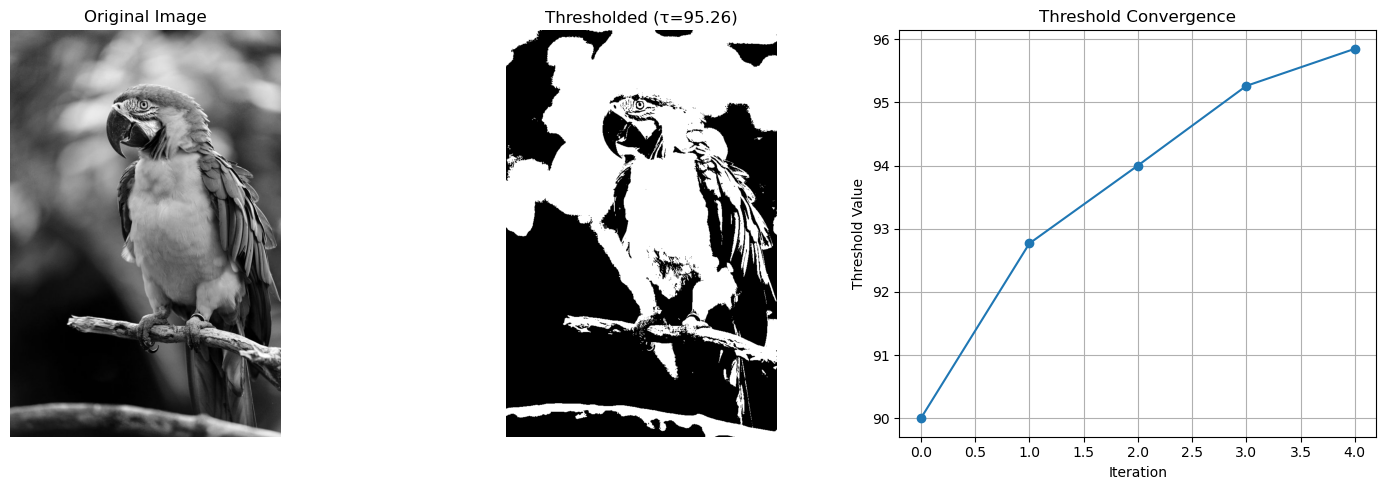

Final threshold: 95.26
Converged in 3 iterations


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def global_adaptive_thresholding(image, initial_threshold=None, epsilon=1, max_iterations=100):

    # Step 1: Initialize threshold (using median if not provided)
    if initial_threshold is None:
        threshold = np.median(image)
    else:
        threshold = initial_threshold

    iterations = 0
    threshold_history = [threshold]  # For tracking convergence

    while iterations < max_iterations:
        # Step 2: Divide pixels into two groups
        group0 = image[image <= threshold]
        group1 = image[image > threshold]

        # Calculate means of both groups
        mu0 = np.mean(group0) if len(group0) > 0 else 0
        mu1 = np.mean(group1) if len(group1) > 0 else 0

        # Calculate new threshold
        new_threshold = (mu0 + mu1) / 2

        # Step 3: Check for convergence
        threshold_change = abs(threshold - new_threshold)
        threshold_history.append(new_threshold)

        if threshold_change <= epsilon:
            break

        # Update threshold for next iteration
        threshold = new_threshold
        iterations += 1

    # Create binary image using final threshold
    binary_image = (image > threshold).astype(np.uint8) * 255

    return threshold, binary_image, iterations, threshold_history


def main():
    # Load an example image (replace with your image path)
    image_path = r"C:\Users\91988\PycharmProjects\elementory\parot.jpg"  # Change this to your image path
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print("Error: Could not read the image.")
        return

    # Perform thresholding
    final_threshold, binary_image, iterations, history = global_adaptive_thresholding(image)

    # Display results
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(binary_image, cmap='gray')
    plt.title(f"Thresholded (τ={final_threshold:.2f})")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.plot(history, 'o-')
    plt.title("Threshold Convergence")
    plt.xlabel("Iteration")
    plt.ylabel("Threshold Value")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Final threshold: {final_threshold:.2f}")
    print(f"Converged in {iterations} iterations")


if __name__ == "__main__":
    main()

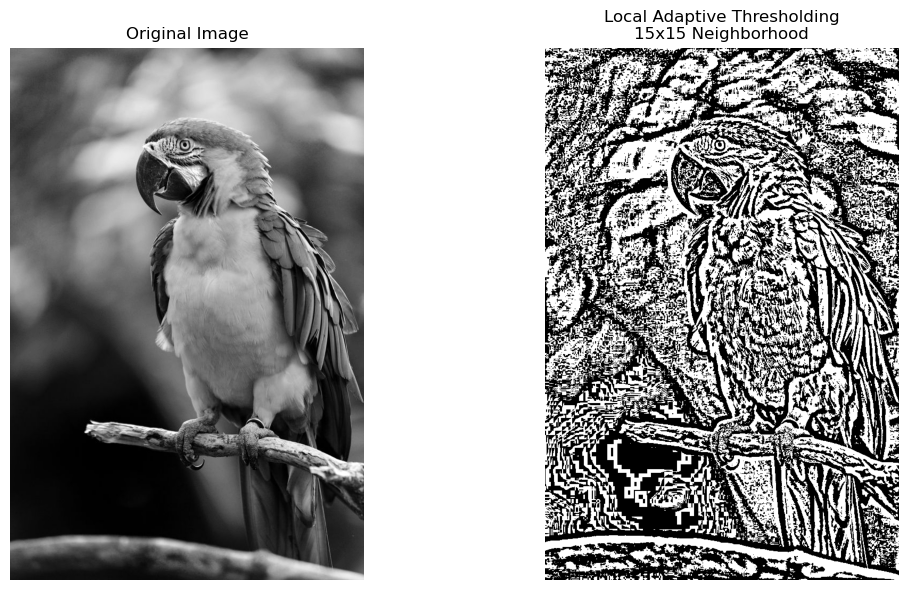

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def local_adaptive_thresholding(image, window_width=15, window_height=15):

    # Validate window dimensions (must be odd)
    if window_width % 2 == 0 or window_height % 2 == 0:
        raise ValueError("Window dimensions must be odd integers")

    # Get image dimensions
    H, W = image.shape
    half_w = window_width // 2
    half_h = window_height // 2

    # Create padded image to handle borders
    padded_img = cv2.copyMakeBorder(image,
                                    half_h, half_h,
                                    half_w, half_w,
                                    cv2.BORDER_REFLECT)

    # Initialize output binary image
    binary_image = np.zeros_like(image, dtype=np.uint8)

    for y in range(H):
        for x in range(W):
            # Calculate neighborhood bounds (Equation 2.19)
            x_start = x  # x is already the position in original image
            x_end = x_start + window_width
            y_start = y  # y is already the position in original image
            y_end = y_start + window_height

            # Extract local neighborhood
            local_region = padded_img[y_start:y_end, x_start:x_end]

            # Calculate local threshold (mean of neighborhood)
            local_threshold = np.mean(local_region)

            # Apply threshold
            binary_image[y, x] = 255 if image[y, x] > local_threshold else 0

    return binary_image


def main():
    # Load an example image (replace with your image path)
    image_path = r"C:\Users\91988\Downloads\parot.jpg"
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print("Error: Could not read the image.")
        return

    # Perform local adaptive thresholding
    window_size = 15  # 15x15 neighborhood as per document example
    binary_image = local_adaptive_thresholding(image, window_size, window_size)

    # Display results
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(binary_image, cmap='gray')
    plt.title(f"Local Adaptive Thresholding\n{window_size}x{window_size} Neighborhood")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()